# Assignment 4a: NumPy and Matplotlib

**At-home assignment — worth 10 points.** When you're done, push your work to your week folder and post a link to your completed **notebook** on the matching Courseworks assignment.

The goal of this assignment is to gain comfort creating, visualizing, and computing with numpy arrays.

:::{admonition} Learning goals
:class: tip
This assignment exercises the scientific Python skills from this section:

- Create new arrays using `linspace` and `arange`
- Compute formulas with numpy arrays (element-wise math + broadcasting)
- Load data from `.npy` files
- Use reductions (`mean`, `std`, `nanmean`, `nanstd`) along specific axes
- Make 1D line plots, scatter plots, and add titles / axis labels
:::

:::{admonition} Working through this notebook
:class: tip
**Download** this notebook using the ⬇ button in the top-right (or copy-paste the cells into a fresh notebook), open it in your environment (JupyterLab on LEAP or Colab), and fill in your solution under each numbered task.

When you're done, follow the [submission instructions](#submission-instructions) at the bottom of the page.
:::

## Part 1: Creating and Manipulating Arrays

Start by importing numpy (as `np`) and matplotlib's `pyplot` (as `plt`). The cell below is empty — type your imports there and run it.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

### 1.1. Create two 2D arrays representing coordinates x, y on the cartesian plan
Both should cover the range (-2, 2) and have 100 points in each direction

In [2]:
# 100 points spanning (-2, 2) in each direction, turned into a 2D grid
x_1d = np.linspace(-2, 2, 100)
y_1d = np.linspace(-2, 2, 100)
x, y = np.meshgrid(x_1d, y_1d)          # x and y are each 2D (100 x 100)
print("x shape:", x.shape, "| y shape:", y.shape)

x shape: (100, 100) | y shape: (100, 100)


### 1.2. Visualize each 2D array using `pcolormesh`

Use the correct coordinates for the x and y axes.

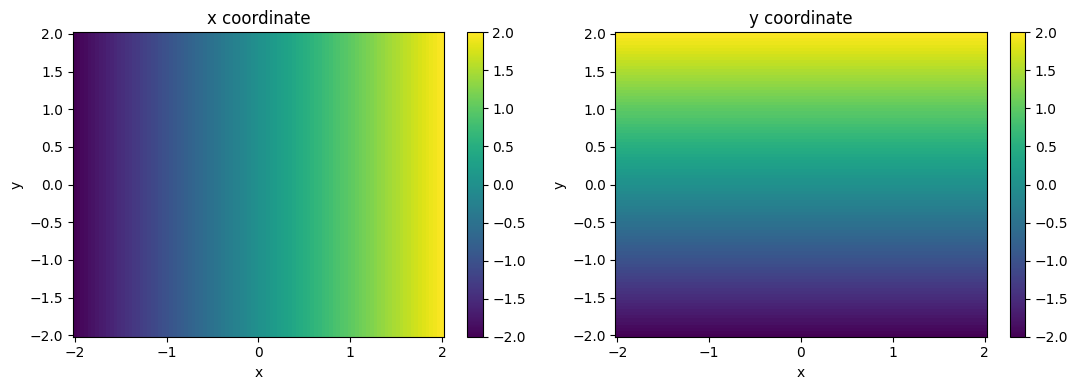

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
pc0 = ax[0].pcolormesh(x_1d, y_1d, x)   # pass the real coords for the axes
ax[0].set_title("x coordinate"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
fig.colorbar(pc0, ax=ax[0])
pc1 = ax[1].pcolormesh(x_1d, y_1d, y)
ax[1].set_title("y coordinate"); ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
fig.colorbar(pc1, ax=ax[1])
plt.tight_layout(); plt.show()

### 1.3 Compute a smooth 2D field and plot it

Using your `x` and `y` arrays, compute the Gaussian "hill"

$$f = e^{-((x-0.5)^2 + 3y^2)}$$

(use `np.exp(...)`). Then plot `f` on the $x$/$y$ plane with `pcolormesh` and add a colorbar.

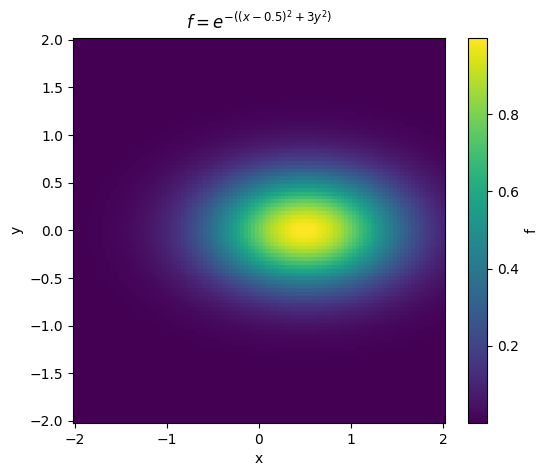

In [4]:
f = np.exp(-((x - 0.5)**2 + 3 * y**2))   # Gaussian "hill"
plt.figure(figsize=(6, 5))
pc = plt.pcolormesh(x_1d, y_1d, f)
plt.colorbar(pc, label="f")
plt.xlabel("x"); plt.ylabel("y")
plt.title(r"$f = e^{-((x-0.5)^2 + 3y^2)}$")
plt.show()

### 1.4 Plot the mean of `f` over the x-axis

Average `f` across the x-direction (`f.mean(axis=...)`) so you're left with a 1D profile as a function of `y`. Plot it.

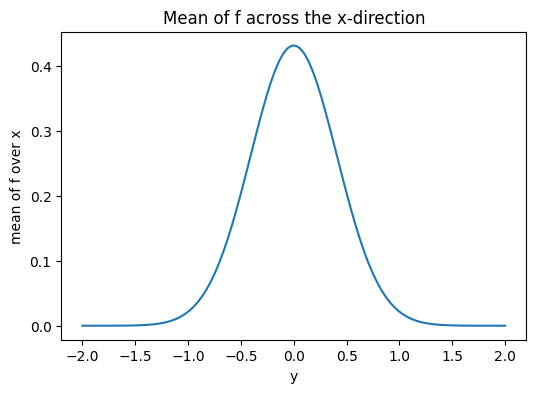

In [5]:
# average over the x-direction (axis=1) -> 1D profile as a function of y
f_vs_y = f.mean(axis=1)
plt.figure(figsize=(6, 4))
plt.plot(y_1d, f_vs_y)
plt.xlabel("y"); plt.ylabel("mean of f over x")
plt.title("Mean of f across the x-direction")
plt.show()

### 1.5 Plot the mean of `f` over the y-axis

Now average across the y-direction instead, leaving a profile as a function of `x`. Plot it.

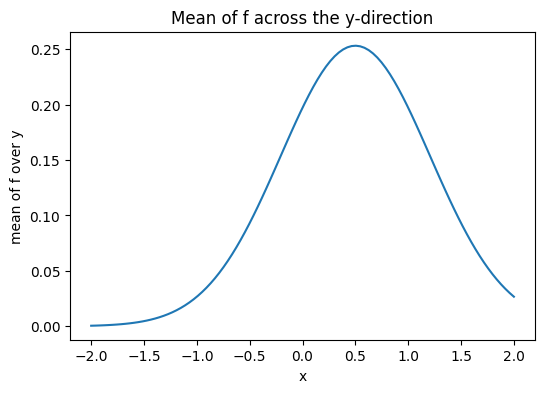

In [6]:
# average over the y-direction (axis=0) -> 1D profile as a function of x
f_vs_x = f.mean(axis=0)
plt.figure(figsize=(6, 4))
plt.plot(x_1d, f_vs_x)
plt.xlabel("x"); plt.ylabel("mean of f over y")
plt.title("Mean of f across the y-direction")
plt.show()

## Part 2: Analyze [ARGO](http://www.argo.ucsd.edu) Data

In this problem, we use real data from ocean profiling floats.
ARGO floats are autonomous robotic instruments that collect Temperature, Salinity, and Pressure data from the ocean. ARGO floats collect one "profile" (a set of messurements at different depths or "levels").

<img src="https://argo.ucsd.edu/wp-content/uploads/sites/361/2020/06/float_cycle_1.png" width="80%" />

Each profile has a single latitude, longitude, and date associated with it, in addition to many different levels.

Let's start by using [pooch](https://www.fatiando.org/pooch/latest/) to download the data files we need for this exercise.
The following code will give you a list of `.npy` files that you can open in the next step.

In [7]:
import pooch
url = "https://github.com/earth-DS-ML/summer_2026/raw/refs/heads/main/assignments/more_matplotlib_data/argo_data_example.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="650948c4b84690d370ad6f8aa9279c165f5302d3d9a7d330d3c0232b9d244e13")
files

Unzipping contents of '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip' to '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip'


['/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip/argo_data_example/salinity.npy',
 '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip/argo_data_example/temperature.npy',
 '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip/argo_data_example/latitude.npy',
 '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip/argo_data_example/pressure.npy',
 '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip/argo_data_example/longitude.npy',
 '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip/argo_data_example/date.npy',
 '/root/.cache/pooch/781f427331dadc92454872cc18f1df31-argo_data_example.zip.unzip/argo_data_example/levels.npy']

### 2.1 Load each data file as a numpy array.

You can use whatever names you want for your arrays, but I recommend

`T`: temperature

`S`: salinity

`P`: pressure

`date`: date

`lat`: latitude

`lon`: longitude

`level`: depth level

**Note**: you have to actually look at the file name (the items in `files`) to know which files corresponds to which variable.


In [8]:
import os
# `files` (from the cell above) is a list of paths -- match each one by its file name
def load(fname, **kw):
    path = [f for f in files if os.path.basename(f) == fname][0]
    return np.load(path, **kw)

T     = load("temperature.npy")
S     = load("salinity.npy")
P     = load("pressure.npy")
level = load("levels.npy")
lat   = load("latitude.npy")
lon   = load("longitude.npy")
date  = load("date.npy", allow_pickle=True)
print("T", T.shape, "| S", S.shape, "| P", P.shape,
      "| level", level.shape, "| lat", lat.shape, "| lon", lon.shape, "| date", date.shape)

T (15, 109) | S (15, 109) | P (15, 109) | level (109,) | lat (15,) | lon (15,) | date (15,)


### 2.2 Examine the shapes of T, S and P compared to `lon`, `lat`, `date` and `level`. How do you think they are related?

Based on the shapes, which dimensions do you think are shared among the arrays?

In [9]:
print("T, S, P shapes :", T.shape, S.shape, P.shape)   # (15, 109)
print("lon, lat, date  :", lon.shape, lat.shape, date.shape)  # (15,)
print("level           :", level.shape)                  # (109,)

# How they're related:
# T, S, P are 2D -> axis 0 = the 15 profiles, axis 1 = the 109 depth levels.
# lon, lat, date are length 15  -> one value per PROFILE (shared with axis 0 of T/S/P).
# level is length 109           -> one value per DEPTH   (shared with axis 1 of T/S/P).

T, S, P shapes : (15, 109) (15, 109) (15, 109)
lon, lat, date  : (15,) (15,) (15,)
level           : (109,)


### 2.3 Make a plot for each column of data in T, S and P (three plots). 

The vertical scale should be the `levels` data. Each plot should have a line for each column of data. It will look messy.

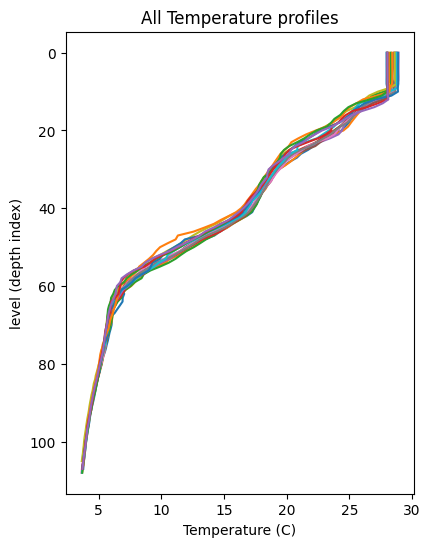

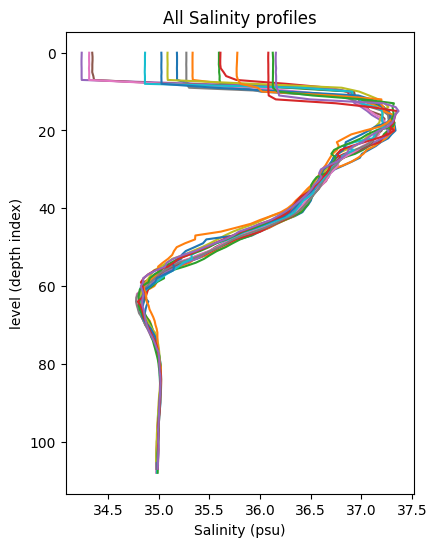

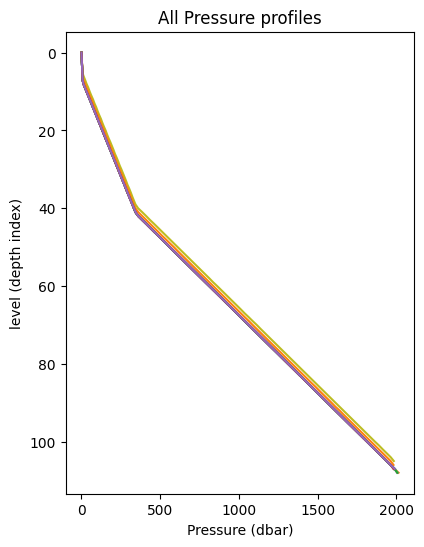

In [10]:
for data, name in [(T, "Temperature (C)"), (S, "Salinity (psu)"), (P, "Pressure (dbar)")]:
    plt.figure(figsize=(4.5, 6))
    plt.plot(data.T, level)          # each column of data.T is one profile -> 15 lines
    plt.gca().invert_yaxis()         # depth increases downward
    plt.xlabel(name); plt.ylabel("level (depth index)")
    plt.title("All " + name.split()[0] + " profiles")
    plt.show()

### 2.4 Compute the mean and standard deviation of each of T, S and P at each depth in `level`.

In [11]:
# "at each depth" -> reduce over the 15 profiles (axis=0), leaving one value per level
T_mean, T_std = T.mean(axis=0), T.std(axis=0)
S_mean, S_std = S.mean(axis=0), S.std(axis=0)
P_mean, P_std = P.mean(axis=0), P.std(axis=0)
print("T_mean first 5 levels:", T_mean[:5])   # NaN wherever a profile is missing at that level

T_mean first 5 levels: [28.4604   28.4614   28.461733 28.461138 28.461933]


### 2.5 Now make three similar plot, but show only the mean T, S and P at each depth. Show [error bars](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) on each plot using the standard deviations. 


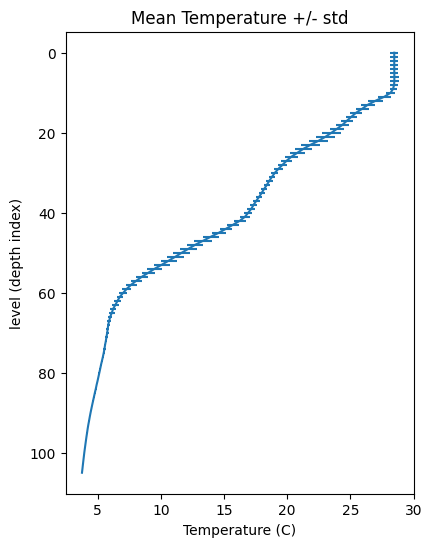

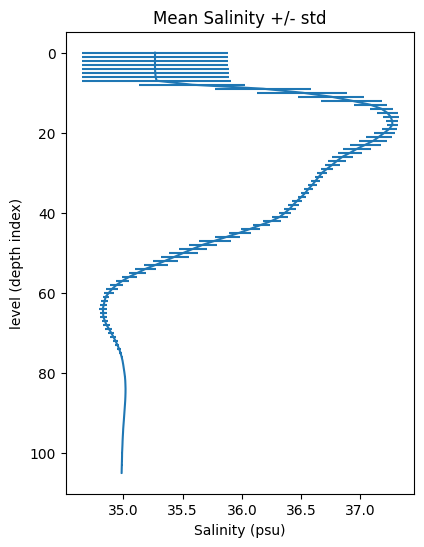

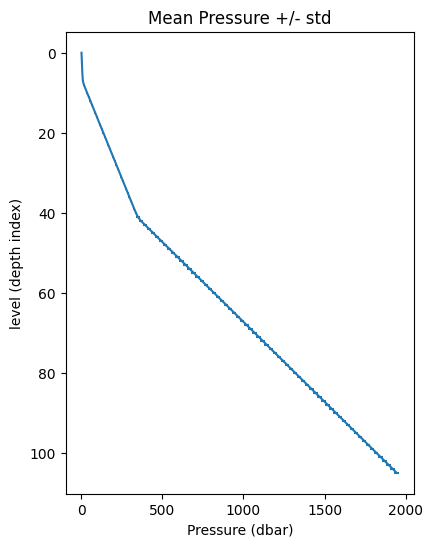

In [12]:
for mean, std, name in [(T_mean, T_std, "Temperature (C)"),
                        (S_mean, S_std, "Salinity (psu)"),
                        (P_mean, P_std, "Pressure (dbar)")]:
    plt.figure(figsize=(4.5, 6))
    plt.errorbar(mean, level, xerr=std)
    plt.gca().invert_yaxis()
    plt.xlabel(name); plt.ylabel("level (depth index)")
    plt.title("Mean " + name.split()[0] + " +/- std")
    plt.show()
# A few depths are blank: one NaN anywhere in a level makes the plain mean/std NaN (fixed in 2.6).

### 2.6 Account For Missing Data

The profiles contain many missing values. These are indicated by the special "Not a Number" value, or `np.nan`.

When you take the mean or standard deviation of data with NaNs in it, the entire result becomes NaN. Instead, if you use the special functions `np.nanmean` and `np.nanstd`, you tell NumPy to ignore the NaNs.

Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

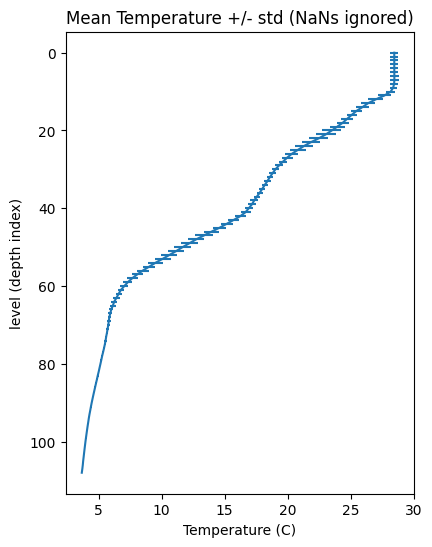

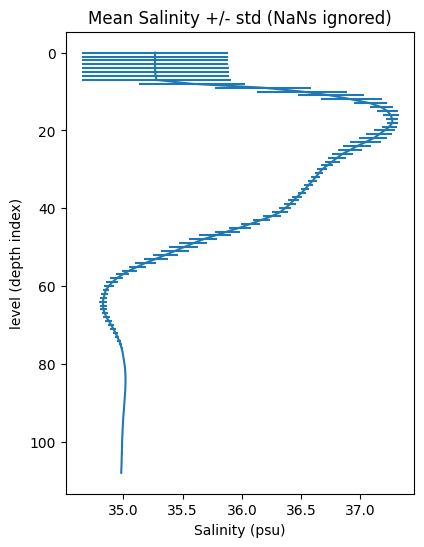

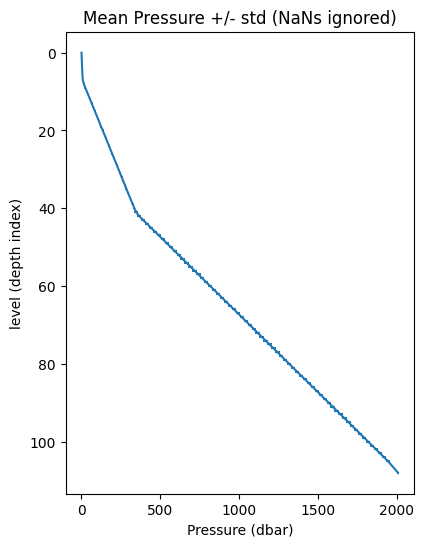

In [13]:
# np.nanmean / np.nanstd ignore the NaNs instead of poisoning the whole result
T_nm, T_ns = np.nanmean(T, axis=0), np.nanstd(T, axis=0)
S_nm, S_ns = np.nanmean(S, axis=0), np.nanstd(S, axis=0)
P_nm, P_ns = np.nanmean(P, axis=0), np.nanstd(P, axis=0)

for mean, std, name in [(T_nm, T_ns, "Temperature (C)"),
                        (S_nm, S_ns, "Salinity (psu)"),
                        (P_nm, P_ns, "Pressure (dbar)")]:
    plt.figure(figsize=(4.5, 6))
    plt.errorbar(mean, level, xerr=std)
    plt.gca().invert_yaxis()
    plt.xlabel(name); plt.ylabel("level (depth index)")
    plt.title("Mean " + name.split()[0] + " +/- std (NaNs ignored)")
    plt.show()

### 2.7 Create a scatter plot of the `lon`, `lat` positions of the ARGO float.

Use the [plt.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) function.

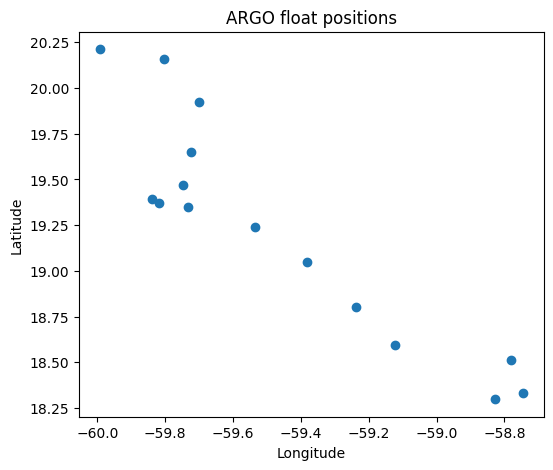

In [14]:
plt.figure(figsize=(6, 5))
plt.scatter(lon, lat)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("ARGO float positions")
plt.show()

## Submission instructions

When you're done, save your completed notebook as `assignment4a.ipynb` inside the current week's folder (e.g. `week4/`) in your private `clmt5405-assignments` GitHub repo. Then push the commit:

```bash
git add <weekN>/assignment4a.ipynb
git commit -m "Submit assignment 4a"
git push
```

Due Sunday night.